In [16]:
#============================
#IMPORT LIBRARIES
#===========================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [17]:
#===========================
#DOWNLOAD DATA
#===========================

brent = yf.download('BZ=F', start='2015-01-01')
wti = yf.download('CL=F', start='2015-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [18]:
#====================================
#CREATE SPREAD
#====================================

brent_close = brent['Close']['BZ=F']
wti_close = wti['Close']['CL=F']
spread = brent_close - wti_close
spread.head()

Date
2015-01-02    3.730000
2015-01-05    3.070000
2015-01-06    3.169998
2015-01-07    2.500000
2015-01-08    2.169998
dtype: float64

In [19]:
#====================================
#CREATE 30-DAY ROLLING AVERAGE
#====================================

spread_ma30 = spread.rolling(window=30).mean()
spread_ma30.head()

Date
2015-01-02   NaN
2015-01-05   NaN
2015-01-06   NaN
2015-01-07   NaN
2015-01-08   NaN
dtype: float64

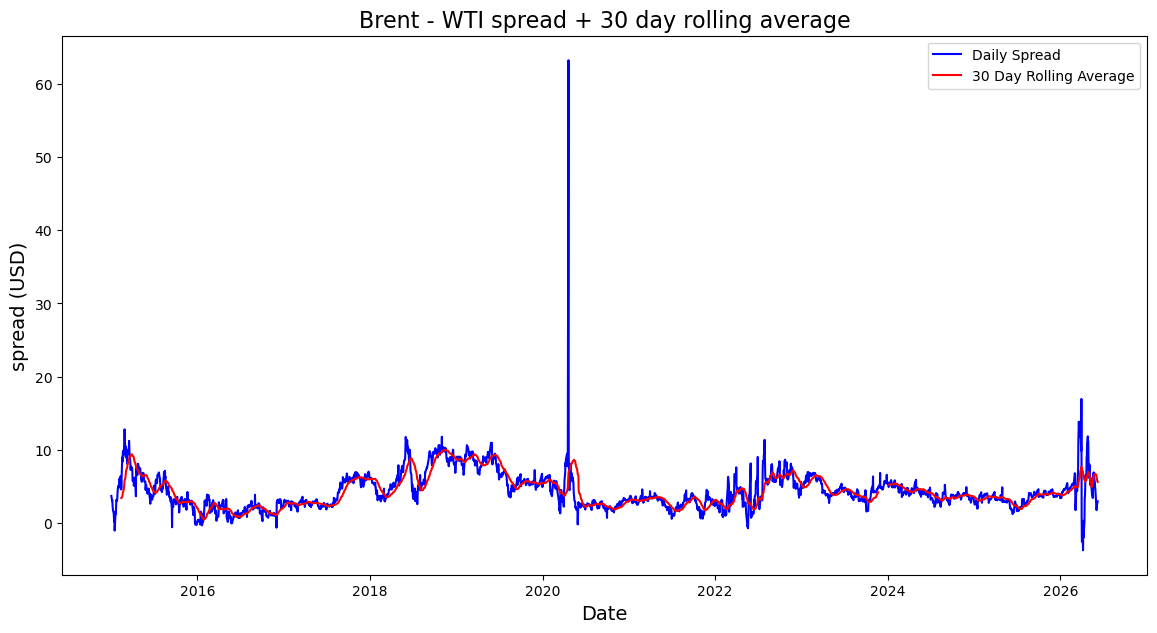

In [20]:
#====================================
#PLOT SPREAD + 30-DAY ROLLING AVERAGE
#====================================

plt.figure(figsize=(14,7))

#Original daily spread
plt.plot(spread, label='Daily Spread', color='blue')

#30-day rolling average
plt.plot(spread_ma30, label='30 Day Rolling Average', color='red')

#Chart title
plt.title('Brent - WTI spread + 30 day rolling average',fontsize=16)

#Axis labels
plt.xlabel('Date', fontsize=14)
plt.ylabel('spread (USD)', fontsize=14)

#Legend
plt.legend()


# Spread + 30 Day Rolling Average Notes
### Long term premium
- Brent crude generally maintained a premium over WTI across the sample period, reflecting differences between globally traded seaborne crude and US domestic crude benchmarks.
### Covid dislocation
- The sharp spread dislocation observed during 2020 coincided with the COVID-19 oil market shock, where unprecedented demand destruction and storage constraints created extreme volatility within US crude markets.
### Rolling average insight 
- The 30-day rolling average smooths short-term volatility and highlights broader trend movements in the Brent-WTI relationship over time.

# ======================================
# 6-Month View + Standard Deviation Bands
# ======================================

In [21]:
#====================================
#DOWNLOAD THE DATA (6 MONTH VIEW)
#====================================

brent_short = yf.download('BZ=F', start='2026-01-01', end='2026-06-01')
wti_short = yf.download('CL=F', start='2026-01-01', end='2026-06-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [22]:
#====================================
#CREATE THE SPREAD
#====================================

brent_short_close = brent_short['Close']['BZ=F']
wti_short_close = wti_short['Close']['CL=F']
spread = brent_short_close - wti_short_close    
spread.head()

Date
2026-01-02    3.430000
2026-01-05    3.439999
2026-01-06    3.570000
2026-01-07    3.969997
2026-01-08    4.230003
dtype: float64

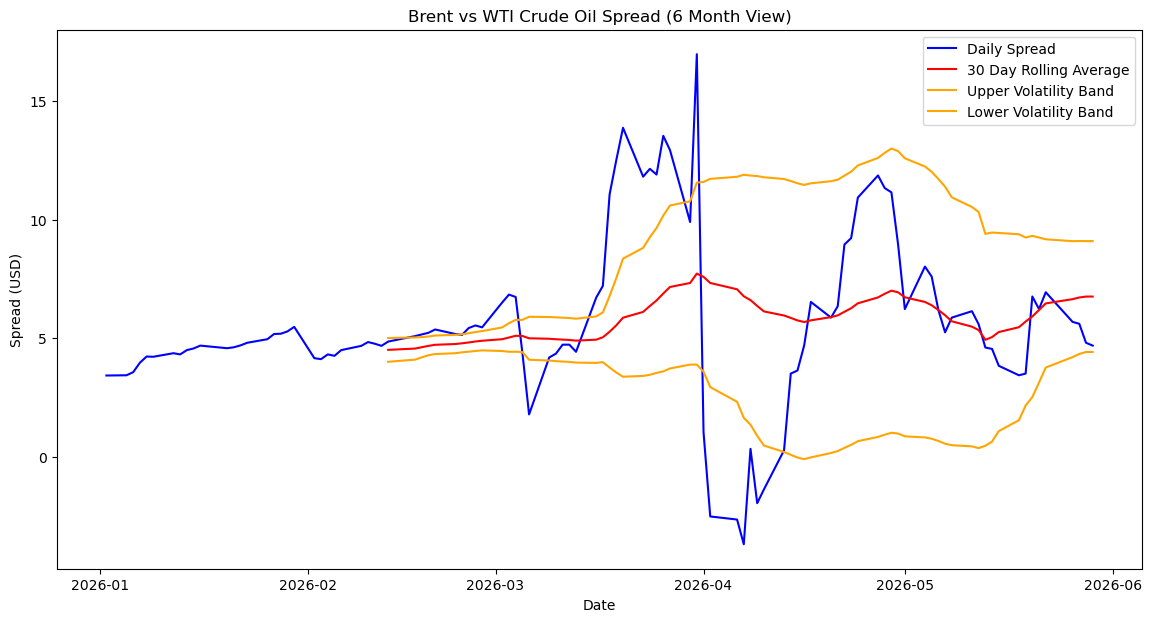

In [23]:
#PLOT THE SPREAD FOR 6 MONTH VIEW
spread_std30 = spread.rolling(window=30).std()
plt.figure(figsize=(14,7))

#Original daily spread
plt.plot(spread, label='Daily Spread', color='blue')

#PLOT 30 DAY ROLLING AVERAGE
spread_30day_avg = spread.rolling(window=30).mean()
plt.plot(spread_30day_avg, label='30 Day Rolling Average', color='red')


#create and plot volatility bands

upper_band= spread_30day_avg + spread_std30
lower_band= spread_30day_avg - spread_std30
plt.plot(upper_band, label='Upper Volatility Band', color='orange')
plt.plot(lower_band, label='Lower Volatility Band', color='orange')

#Chart Labels
plt.xlabel('Date')
plt.ylabel('Spread (USD)')

#Chart title and legend
plt.title('Brent vs WTI Crude Oil Spread (6 Month View)')
plt.legend()


plt.show()


### Analytical Points | Brent-WTI Spread & Volatility Analysis
##### Elevated spread volatility during March/April suggests heightened geopolitical risk pricing
- The sharp increase in spread volatility during March and April coincided with heightened geopolitical tensions in the Middle East, particularly surrounding Iran and broader regional instability, which likely increased geopolitical risk premiums within global crude markets, and the continued disruption of the Strait of Hormuz.
##### Spread dislocations indicate temporary imbalance between global and US crude pricing
- Significant deviations of the spread beyond the rolling volatility bands may indicate temporary pricing dislocations between internationally traded Brent crude and domestically benchmarked US WTI crude. Market participants positioned for further Brent-WTI spread widening as global supply concerns intensified.
##### The widening volatility bands suggest a transition into a higher-risk market regime
- Expansion of the rolling standard deviation bands during periods of elevated spread movement suggests a transition from relatively stable pricing conditions into a higher-volatility market environment. Elevated market uncertainty likely created opportunities for volatility-focused trading strategies during periods of sharp spread movement.
##### Mean Reversion May/June 
- From mid-May into June 2026, narrowing volatility bands and moderation in spread movements suggested partial mean reversion and improving market stabilisation following the earlier period of elevated uncertainty.
##### Throughou the period summary
- Across the broader January–June 2026 period, the rolling average remained elevated relative to earlier levels, potentially reflecting ongoing structural uncertainty surrounding global supply balances, OPEC+ policy expectations, and broader macroeconomic conditions.

In [24]:
######################################################
#DOWNLOAD DXY DATA (US DOLLAR INDEX)
######################################################

#IMPORT LIBRARY
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
dxy = yf.download('DX-Y.NYB', start='2026-01-01')



[*********************100%***********************]  1 of 1 completed


In [25]:
#####################################################
#EXTRACT DXY CLOSE PRICE
######################################################
DXY_CLOSE = dxy['Close']['DX-Y.NYB']
DXY_CLOSE.head()

Date
2026-01-02    98.419998
2026-01-05    98.269997
2026-01-06    98.580002
2026-01-07    98.680000
2026-01-08    98.930000
Name: DX-Y.NYB, dtype: float64

In [26]:
#####################################################
#DOWNLOAD BRENT & WTI DATA
######################################################

brent_short = yf.download('BZ=F', start='2026-01-01')
wti_short = yf.download('CL=F', start='2026-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [27]:
#####################################################
#EXTRACT CLOSING PRICES
######################################################

brent_short_close = brent_short['Close']['BZ=F']
wti_short_close = wti_short['Close']['CL=F']

In [28]:
#####################################################
#CREATE BRENT WTI SPREAD
######################################################

spread_short = brent_short_close - wti_short_close
spread_short.head()

Date
2026-01-02    3.430000
2026-01-05    3.439999
2026-01-06    3.570000
2026-01-07    3.969997
2026-01-08    4.230003
dtype: float64

In [29]:
#####################################################
#NORMALISE DATA
#####################################################

spread_normalised = (spread_short / spread_short.iloc[0])*100
DXY_normalised = (DXY_CLOSE / DXY_CLOSE.iloc[0])*100

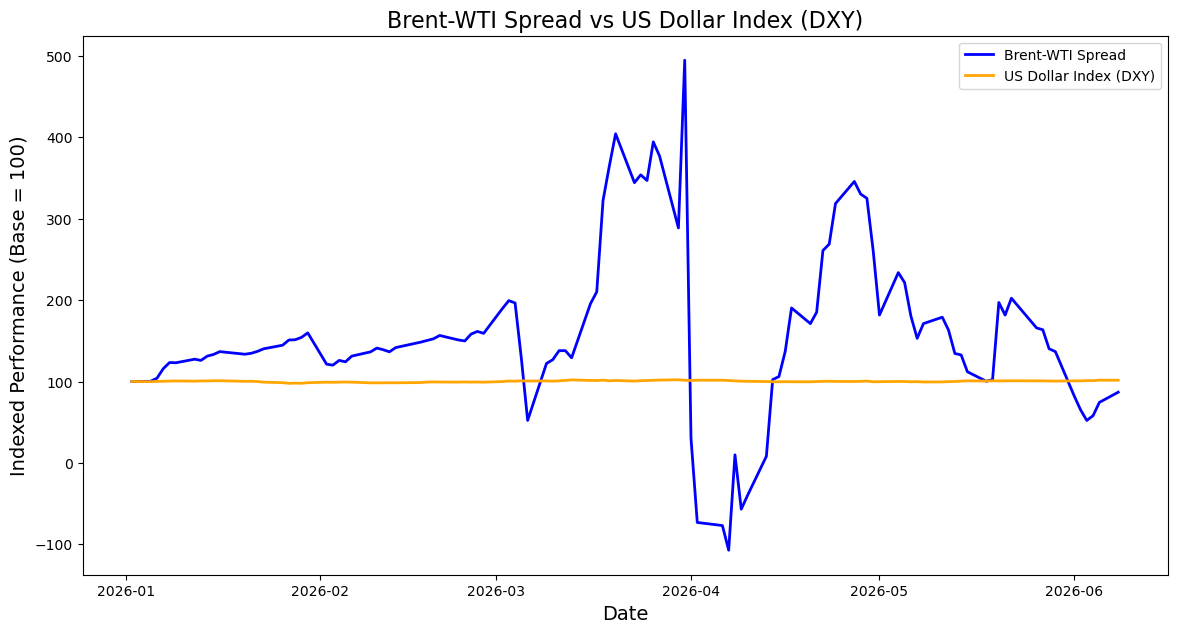

In [30]:
#####################################################
#PLOT BRENT-WTI SPREAD VS DXY
#####################################################

plt.figure(figsize=(14,7))

#Brent-WTI Spread
plt.plot(spread_normalised, label='Brent-WTI Spread', linewidth=2, color='blue')
#DXY
plt.plot(DXY_normalised, label='US Dollar Index (DXY)', linewidth=2, color='orange')
#Chart title and labels
plt.title('Brent-WTI Spread vs US Dollar Index (DXY)',fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Indexed Performance (Base = 100)', fontsize=14)

#Legend
plt.legend()
#Show chart
plt.show()

### oil spread volatility was driven more by commodity-specific/geopolitical factors than broader USD movements.
- Despite relative stability within the US Dollar Index throughout the period, the Brent-WTI spread experienced substantial volatility and dislocation, suggesting that commodity-specific geopolitical and supply-side dynamics exerted a significantly greater influence on spread behaviour than broader macro-currency movements

Next time would be more beneficial to look at brent outright price against the us dollar index as the spread just smothers the dxy index

In [31]:
#######################################
#CREATE ROLLING CORRELATION
########################################

rolling_corr = spread_normalised.rolling(window=30).corr(DXY_normalised)


In [32]:
#############################
#this calculates above, the changing correlation over time between the Brent-WTI spread and the US Dollar Index (DXY) using a 30-day rolling window.
#############################

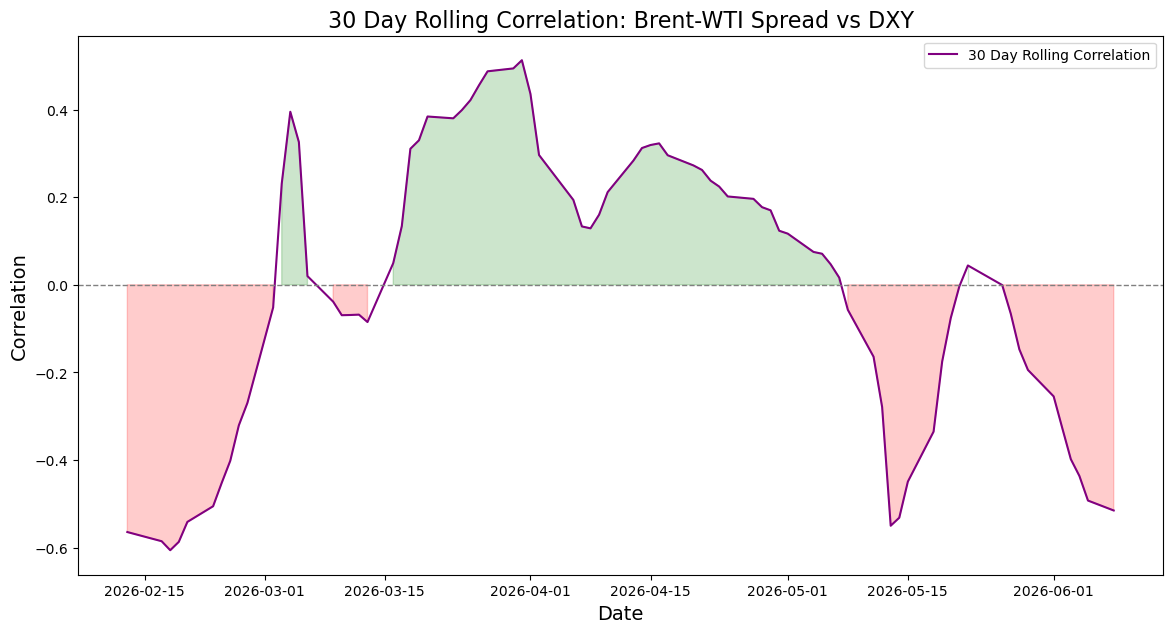

In [33]:
#####################################################
# PLOT ROLLING CORRELATION
#####################################################
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))


plt.plot(rolling_corr, label='30 Day Rolling Correlation', color='purple')
# fill positive correlation green, negative red
plt.fill_between(rolling_corr.index, rolling_corr, 0,
                 where=(rolling_corr >0), color='green', alpha=0.2)
plt.fill_between(rolling_corr.index, rolling_corr, 0,
                 where=(rolling_corr <0), color='red', alpha=0.2)
#add zero reference line
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
#Chart title and labels
plt.title('30 Day Rolling Correlation: Brent-WTI Spread vs DXY', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Correlation', fontsize=14)
plt.legend()
plt.show()

- The rolling correlation between the Brent-WTI spread and the US Dollar Index remained highly unstable throughout the observed period, suggesting that market dynamics shifted across multiple trading regimes.
- During February 2026, the correlation moved into strongly negative territory, indicating that Brent-WTI spread movements were inversely related to US Dollar Index performance.
- Between March and April 2026, correlation shifted into positive territory, potentially reflecting a period where broader macro sentiment and geopolitical concerns simultaneously influenced both markets.
- Elevated geopolitical uncertainty during the March–April period may have disrupted traditional commodity-currency relationships, with oil-specific risk premiums exerting greater influence on spread behaviour.